In [ ]:
!pip install transformers datasets torch scikit-learn -q

In [ ]:
# Veri setini Google Drive'a yüklemek yerine direkt Colab'a yükleyeceğiz
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Bu kod çalışınca dosya seçme penceresi açılacak

Saving PhiUSIIL_Phishing_URL_Dataset.csv to PhiUSIIL_Phishing_URL_Dataset.csv


In [ ]:
# Veriyi oku ve kontrol et
import pandas as pd

# Dosya adını tam olarak yazın
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

# Sadece ihtiyacımız olan sütunları al
df = df[['URL', 'label']]

# Kontrol
print("Toplam kayıt:", len(df))
print("\nLabel dağılımı:")
print(df['label'].value_counts())
print("\nİlk 5 satır:")
print(df.head())
print("\nEksik veri var mı:")
print(df.isnull().sum())

Toplam kayıt: 235795

Label dağılımı:
label
1    134850
0    100945
Name: count, dtype: int64

İlk 5 satır:
                                  URL  label
0    https://www.southbankmosaics.com      1
1            https://www.uni-mainz.de      1
2      https://www.voicefmradio.co.uk      1
3         https://www.sfnmjournal.com      1
4  https://www.rewildingargentina.org      1

Eksik veri var mı:
URL      0
label    0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# 1. URL'leri string yap ve boşlukları temizle
df['URL'] = df['URL'].astype(str).str.strip()

# 2. Duplicate URL varsa kaldır
before = len(df)
df = df.drop_duplicates(subset='URL')
after = len(df)
print(f"Duplicate kaldırıldı: {before - after} adet")
print(f"Kalan kayıt: {after}")

# 3. Önce %80 train, %20 temp ayır
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# 4. Temp'i %50/%50 → validation ve test olarak böl
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

# 5. Kontrol
print(f"\nTrain seti:      {len(train_df)} kayıt")
print(f"Validation seti: {len(val_df)} kayıt")
print(f"Test seti:       {len(test_df)} kayıt")

print(f"\nTrain label dağılımı:")
print(train_df['label'].value_counts())
print(f"\nValidation label dağılımı:")
print(val_df['label'].value_counts())
print(f"\nTest label dağılımı:")
print(test_df['label'].value_counts())

Duplicate kaldırıldı: 425 adet
Kalan kayıt: 235370

Train seti:      188296 kayıt
Validation seti: 23537 kayıt
Test seti:       23537 kayıt

Train label dağılımı:
label
1    107880
0     80416
Name: count, dtype: int64

Validation label dağılımı:
label
1    13485
0    10052
Name: count, dtype: int64

Test label dağılımı:
label
1    13485
0    10052
Name: count, dtype: int64


In [ ]:
from transformers import DistilBertTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Tokenizer'ı yükle
print("Tokenizer yükleniyor...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("Tokenizer yüklendi ✓")

# 2. Dataset sınıfı tanımla
class URLDataset(Dataset):
    def __init__(self, urls, labels, tokenizer, max_length=128):
        self.urls = urls.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.urls[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# 3. Dataset objelerini oluştur
train_dataset = URLDataset(train_df['URL'], train_df['label'], tokenizer)
val_dataset   = URLDataset(val_df['URL'],   val_df['label'],   tokenizer)
test_dataset  = URLDataset(test_df['URL'],  test_df['label'],  tokenizer)

# 4. DataLoader'ları oluştur
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"\nTrain batch sayısı:      {len(train_loader)}")
print(f"Validation batch sayısı: {len(val_loader)}")
print(f"Test batch sayısı:       {len(test_loader)}")

# 5. Örnek bir URL'nin nasıl tokenize edildiğini göster
ornek = tokenizer("https://www.phishing-example.com/login?user=abc",
                   max_length=128, padding='max_length',
                   truncation=True, return_tensors='pt')
print(f"\nÖrnek URL token sayısı: {ornek['attention_mask'].sum().item()}")
print(f"Token IDs (ilk 15):     {ornek['input_ids'][0][:15].tolist()}")

Tokenizer yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer yüklendi ✓

Train batch sayısı:      5885
Validation batch sayısı: 736
Test batch sayısı:       736

Örnek URL token sayısı: 21
Token IDs (ilk 15):     [101, 16770, 1024, 1013, 1013, 7479, 1012, 13569, 12227, 1011, 2742, 1012, 4012, 1013, 8833]


In [ ]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 1. GPU kontrolü
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# 2. Modeli yükle
print("\nModel yükleniyor...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model = model.to(device)
print("Model yüklendi ✓")

# 3. Optimizer ve scheduler
EPOCHS = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# 4. Değerlendirme fonksiyonu
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids     = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels        = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader)
    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall    = recall_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1

print("\nEğitime hazır ✓")
print(f"Toplam epoch: {EPOCHS}")
print(f"Toplam adım:  {total_steps}")

Kullanılan cihaz: cuda
GPU: Tesla T4

Model yükleniyor...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model yüklendi ✓

Eğitime hazır ✓
Toplam epoch: 3
Toplam adım:  17655


In [ ]:
import time

# Sonuçları kaydetmek için
history = {
    'train_loss': [],
    'val_loss': [], 'val_accuracy': [],
    'val_precision': [], 'val_recall': [], 'val_f1': []
}

best_val_f1 = 0
best_model_path = 'best_distilbert_phiusiil.pt'

print("=" * 60)
print("EĞİTİM BAŞLIYOR")
print("=" * 60)

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    start_time = time.time()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        # Her 500 adımda ilerleme göster
        if (step + 1) % 500 == 0:
            elapsed = time.time() - start_time
            avg_so_far = total_train_loss / (step + 1)
            print(f"  Epoch {epoch+1} | Adım {step+1}/{len(train_loader)} "
                  f"| Loss: {avg_so_far:.4f} | Süre: {elapsed/60:.1f} dk")

    avg_train_loss = total_train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # --- VALIDATION ---
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(model, val_loader, device)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)
    history['val_f1'].append(val_f1)

    epoch_time = (time.time() - start_time) / 60

    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{EPOCHS} TAMAMLANDI ({epoch_time:.1f} dk)")
    print(f"  Train Loss:      {avg_train_loss:.4f}")
    print(f"  Val Loss:        {val_loss:.4f}")
    print(f"  Val Accuracy:    {val_acc:.4f}")
    print(f"  Val Precision:   {val_prec:.4f}")
    print(f"  Val Recall:      {val_rec:.4f}")
    print(f"  Val F1-Score:    {val_f1:.4f}")

    # En iyi modeli kaydet
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ En iyi model kaydedildi! (F1: {best_val_f1:.4f})")
    print(f"{'='*60}\n")

print("EĞİTİM TAMAMLANDI!")
print(f"En iyi Validation F1: {best_val_f1:.4f}")

EĞİTİM BAŞLIYOR
  Epoch 1 | Adım 500/5885 | Loss: 0.2722 | Süre: 3.0 dk
  Epoch 1 | Adım 1000/5885 | Loss: 0.1437 | Süre: 6.0 dk
  Epoch 1 | Adım 1500/5885 | Loss: 0.1010 | Süre: 9.0 dk
  Epoch 1 | Adım 2000/5885 | Loss: 0.0800 | Süre: 12.0 dk
  Epoch 1 | Adım 2500/5885 | Loss: 0.0664 | Süre: 15.0 dk
  Epoch 1 | Adım 3000/5885 | Loss: 0.0576 | Süre: 17.9 dk
  Epoch 1 | Adım 3500/5885 | Loss: 0.0515 | Süre: 20.9 dk
  Epoch 1 | Adım 4000/5885 | Loss: 0.0466 | Süre: 23.9 dk
  Epoch 1 | Adım 4500/5885 | Loss: 0.0433 | Süre: 26.9 dk
  Epoch 1 | Adım 5000/5885 | Loss: 0.0403 | Süre: 29.9 dk
  Epoch 1 | Adım 5500/5885 | Loss: 0.0374 | Süre: 32.9 dk

EPOCH 1/3 TAMAMLANDI (36.7 dk)
  Train Loss:      0.0357
  Val Loss:        0.0120
  Val Accuracy:    0.9979
  Val Precision:   0.9964
  Val Recall:      1.0000
  Val F1-Score:    0.9982
  ✓ En iyi model kaydedildi! (F1: 0.9982)

  Epoch 2 | Adım 500/5885 | Loss: 0.0083 | Süre: 3.0 dk
  Epoch 2 | Adım 1000/5885 | Loss: 0.0089 | Süre: 6.0 dk
  Epoc

En iyi model yüklendi ✓

TEST SONUÇLARI
Test Loss:        0.0116
Test Accuracy:    0.9985
Test Precision:   0.9974
Test Recall:      0.9999
Test F1-Score:    0.9987


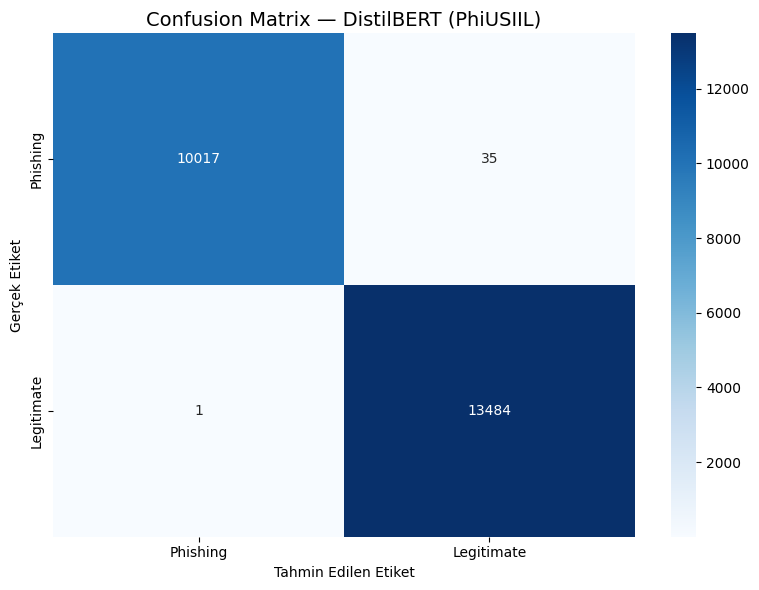

Confusion matrix kaydedildi ✓

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     10052
  Legitimate       1.00      1.00      1.00     13485

    accuracy                           1.00     23537
   macro avg       1.00      1.00      1.00     23537
weighted avg       1.00      1.00      1.00     23537



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. En iyi modeli yükle
model.load_state_dict(torch.load(best_model_path))
print("En iyi model yüklendi ✓")

# 2. Test setinde değerlendir
test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(model, test_loader, device)

print("\n" + "="*60)
print("TEST SONUÇLARI")
print("="*60)
print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Test Precision:   {test_prec:.4f}")
print(f"Test Recall:      {test_rec:.4f}")
print(f"Test F1-Score:    {test_f1:.4f}")
print("="*60)

# 3. Confusion matrix için tahminleri topla
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# 4. Confusion Matrix çiz
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing', 'Legitimate'],
            yticklabels=['Phishing', 'Legitimate'])
plt.title('Confusion Matrix — DistilBERT (PhiUSIIL)', fontsize=14)
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen Etiket')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix kaydedildi ✓")

# 5. Classification report
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(all_labels, all_preds,
      target_names=['Phishing', 'Legitimate']));

Toplam test örneği:              23537
Yanlış sınıflandırılan:          36
Doğruluk (hata bazlı):           %99.85

False Positive (Phishing → Legitimate): 35
False Negative (Legitimate → Phishing): 1

--- FALSE POSITIVE örnekleri (Phishing iken Legitimate sanıldı) ---
  URL: https://www.ndnmag.fr
  URL: https://www.factor-a1.com
  URL: https://www.ownagedomains.com
  URL: https://www.sharestion.com
  URL: https://www.cabomarlini.com

--- FALSE NEGATIVE örnekleri (Legitimate iken Phishing sanıldı) ---
  URL: https://www.upload-4ever.com


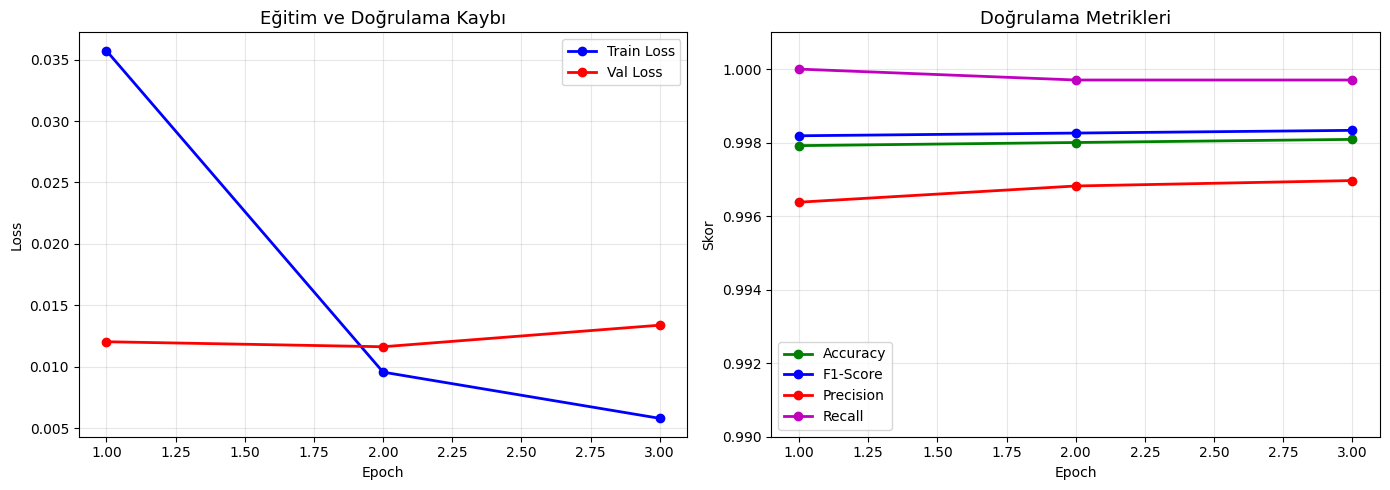

Eğitim grafikleri kaydedildi ✓


In [ ]:
import numpy as np

# 1. Yanlış sınıflandırılan örnekleri bul
all_preds_arr  = np.array(all_preds)
all_labels_arr = np.array(all_labels)
test_urls      = test_df['URL'].values

wrong_idx = np.where(all_preds_arr != all_labels_arr)[0]

print(f"Toplam test örneği:              {len(all_labels_arr)}")
print(f"Yanlış sınıflandırılan:          {len(wrong_idx)}")
print(f"Doğruluk (hata bazlı):           %{(1 - len(wrong_idx)/len(all_labels_arr))*100:.2f}")

# 2. Hata türlerini ayır
# False Positive: Gerçekte Phishing (0), model Legitimate (1) dedi
# False Negative: Gerçekte Legitimate (1), model Phishing (0) dedi
fp_idx = np.where((all_labels_arr == 0) & (all_preds_arr == 1))[0]
fn_idx = np.where((all_labels_arr == 1) & (all_preds_arr == 0))[0]

print(f"\nFalse Positive (Phishing → Legitimate): {len(fp_idx)}")
print(f"False Negative (Legitimate → Phishing): {len(fn_idx)}")

# 3. Hatalı örnekleri göster
print("\n--- FALSE POSITIVE örnekleri (Phishing iken Legitimate sanıldı) ---")
for i in fp_idx[:5]:
    print(f"  URL: {test_urls[i]}")

print("\n--- FALSE NEGATIVE örnekleri (Legitimate iken Phishing sanıldı) ---")
for i in fn_idx[:5]:
    print(f"  URL: {test_urls[i]}")

# 4. Epoch bazlı eğitim grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, EPOCHS + 1)

# Loss grafiği
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Eğitim ve Doğrulama Kaybı', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metrik grafiği
axes[1].plot(epochs, history['val_accuracy'],  'g-o',  label='Accuracy',  linewidth=2)
axes[1].plot(epochs, history['val_f1'],        'b-o',  label='F1-Score',  linewidth=2)
axes[1].plot(epochs, history['val_precision'], 'r-o',  label='Precision', linewidth=2)
axes[1].plot(epochs, history['val_recall'],    'm-o',  label='Recall',    linewidth=2)
axes[1].set_title('Doğrulama Metrikleri', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Skor')
axes[1].set_ylim([0.99, 1.001])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Eğitim grafikleri kaydedildi ✓")

In [ ]:
# LIME kurulumu
!pip install lime -q
print("LIME kuruldu ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME kuruldu ✓


In [ ]:
import lime
from lime.lime_text import LimeTextExplainer
import numpy as np

# 1. LIME için tahmin fonksiyonu
def predict_proba(urls):
    model.eval()
    probs = []

    batch_size = 16
    for i in range(0, len(urls), batch_size):
        batch_urls = urls[i:i+batch_size]
        encoding = tokenizer(
            batch_urls,
            max_length=128,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            prob = torch.softmax(outputs.logits, dim=1).cpu().numpy()
            probs.extend(prob)

    return np.array(probs)

# 2. LIME explainer oluştur
explainer = LimeTextExplainer(
    class_names=['Phishing', 'Legitimate'],
    char_level=False,
    split_expression=r'[/\.\-\_\?\=\&\:\@]'  # URL ayırıcıları
)

print("LIME hazır ✓")

# 3. Analiz edilecek örnek URL'leri seç
# 3 phishing + 3 legitimate + 2 yanlış sınıflandırılan
ornek_urls = {
    'Phishing 1':    test_df['URL'].values[test_df['label'].values == 0][0],
    'Phishing 2':    test_df['URL'].values[test_df['label'].values == 0][1],
    'Phishing 3':    test_df['URL'].values[test_df['label'].values == 0][2],
    'Legitimate 1':  test_df['URL'].values[test_df['label'].values == 1][0],
    'Legitimate 2':  test_df['URL'].values[test_df['label'].values == 1][1],
    'Legitimate 3':  test_df['URL'].values[test_df['label'].values == 1][2],
    'False Positive': test_urls[fp_idx[0]],  # Yanlış sınıflanan phishing
    'False Negative': test_urls[fn_idx[0]],  # Yanlış sınıflanan legitimate
}

print("Analiz edilecek URL'ler:")
for name, url in ornek_urls.items():
    pred = predict_proba([url])[0]
    print(f"  {name:15s}: {url[:60]}")
    print(f"                   → Phishing: %{pred[0]*100:.1f} | Legitimate: %{pred[1]*100:.1f}")

LIME hazır ✓
Analiz edilecek URL'ler:
  Phishing 1     : http://www.daumhelp.net
                   → Phishing: %100.0 | Legitimate: %0.0
  Phishing 2     : https://sitebuilder186891.dynadot.com/
                   → Phishing: %100.0 | Legitimate: %0.0
  Phishing 3     : https://sharmansweetsonline.com/updsoci/sg/cc.php
                   → Phishing: %100.0 | Legitimate: %0.0
  Legitimate 1   : https://www.breinersdorfer.com
                   → Phishing: %0.0 | Legitimate: %100.0
  Legitimate 2   : https://www.sykea.co.uk
                   → Phishing: %0.0 | Legitimate: %100.0
  Legitimate 3   : https://www.strataarchitects.com
                   → Phishing: %0.0 | Legitimate: %100.0
  False Positive : https://www.ndnmag.fr
                   → Phishing: %0.0 | Legitimate: %100.0
  False Negative : https://www.upload-4ever.com
                   → Phishing: %79.2 | Legitimate: %20.8


LIME ANALİZİ BAŞLIYOR

Analiz ediliyor: Phishing 1...


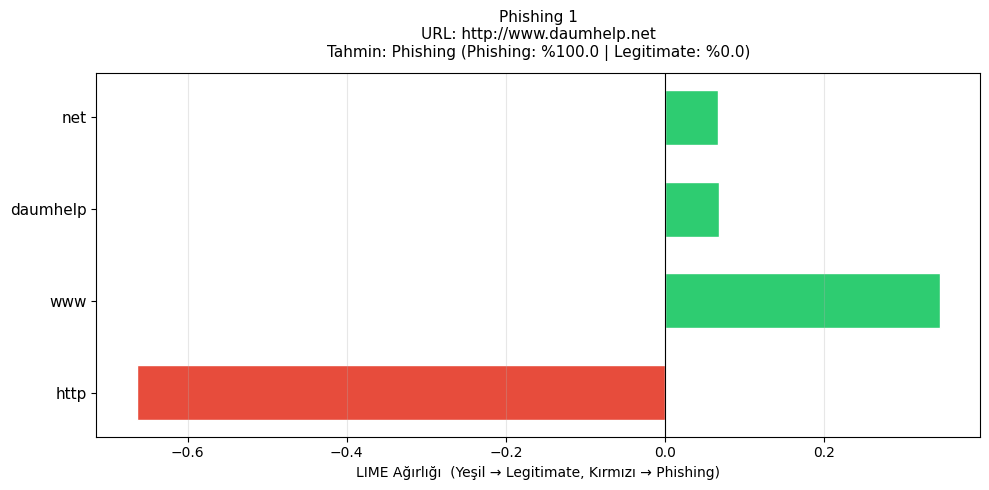

  Kaydedildi: lime_phishing_1.png ✓

Analiz ediliyor: Phishing 2...


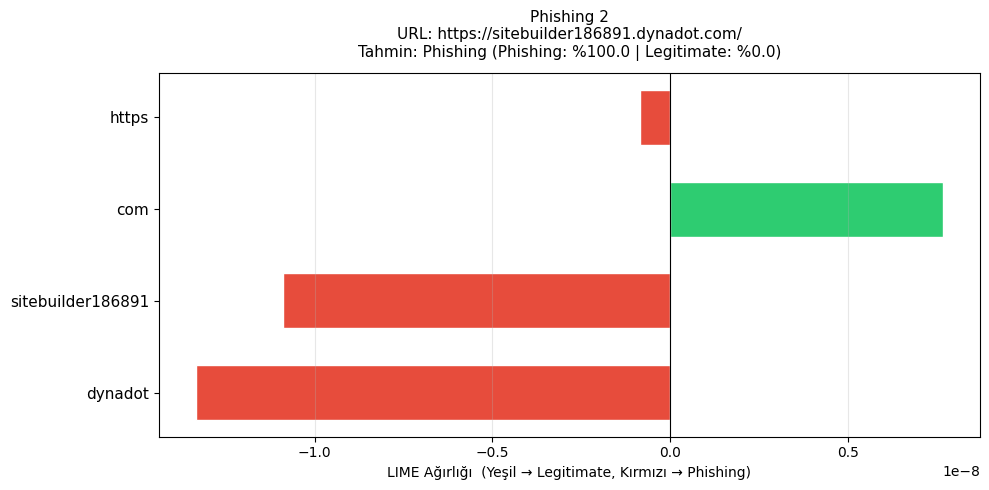

  Kaydedildi: lime_phishing_2.png ✓

Analiz ediliyor: Phishing 3...


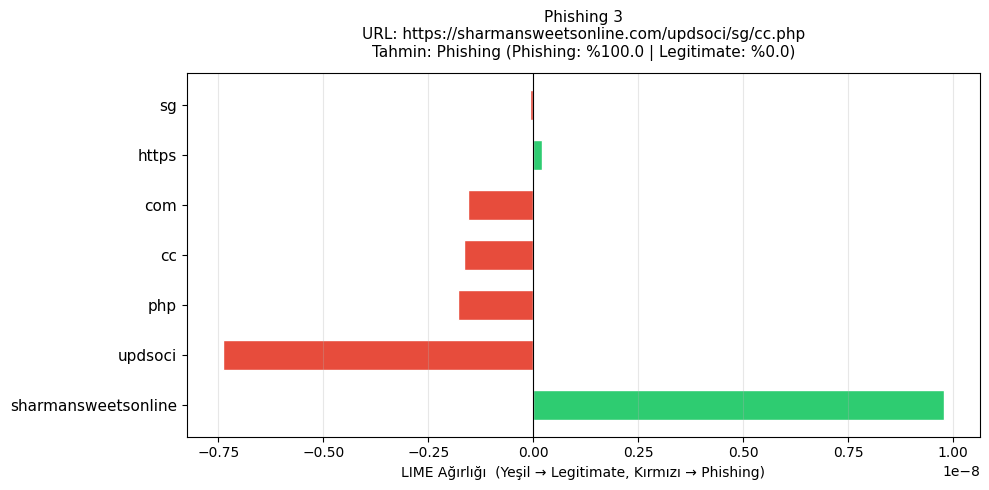

  Kaydedildi: lime_phishing_3.png ✓

Analiz ediliyor: Legitimate 1...


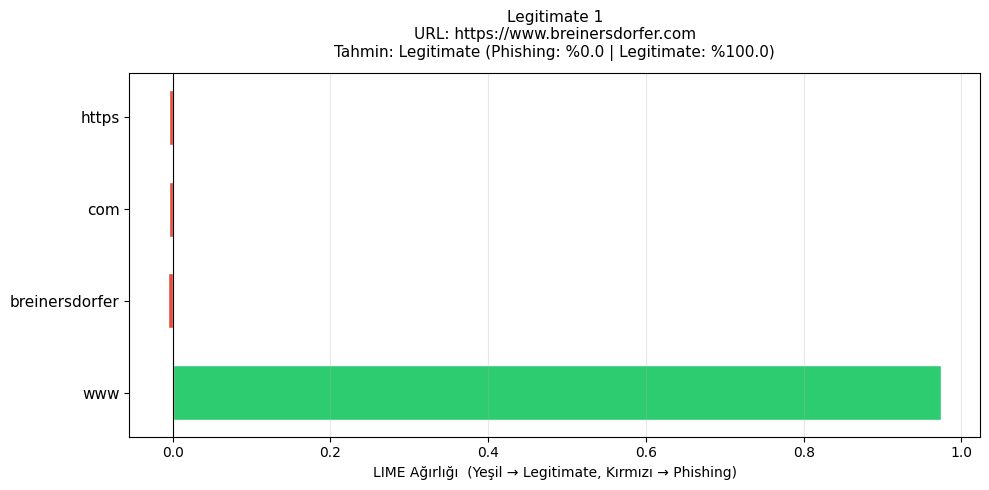

  Kaydedildi: lime_legitimate_1.png ✓

Analiz ediliyor: Legitimate 2...


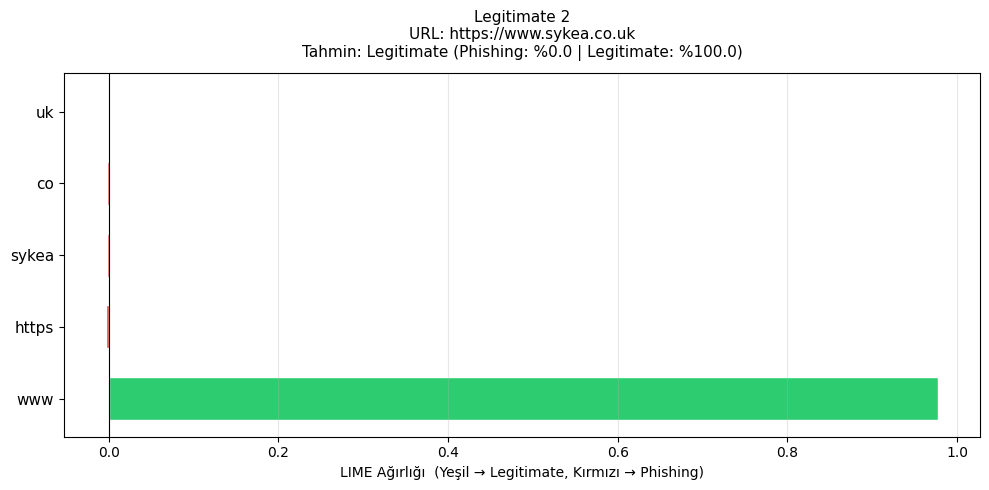

  Kaydedildi: lime_legitimate_2.png ✓

Analiz ediliyor: Legitimate 3...


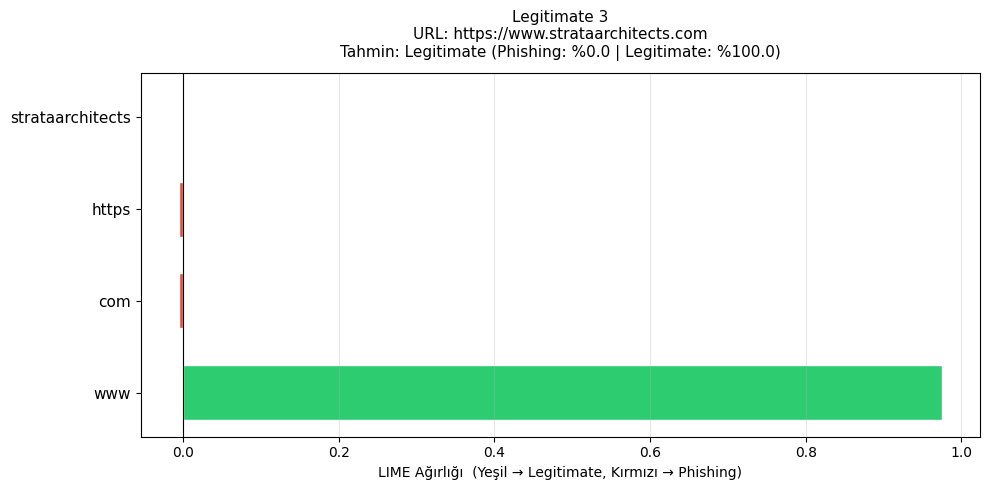

  Kaydedildi: lime_legitimate_3.png ✓

Analiz ediliyor: False Positive...


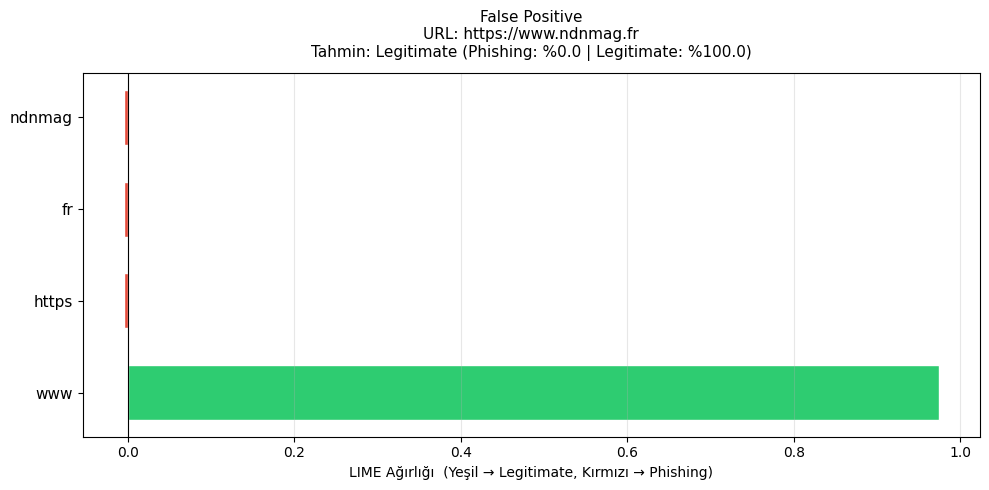

  Kaydedildi: lime_false_positive.png ✓

Analiz ediliyor: False Negative...


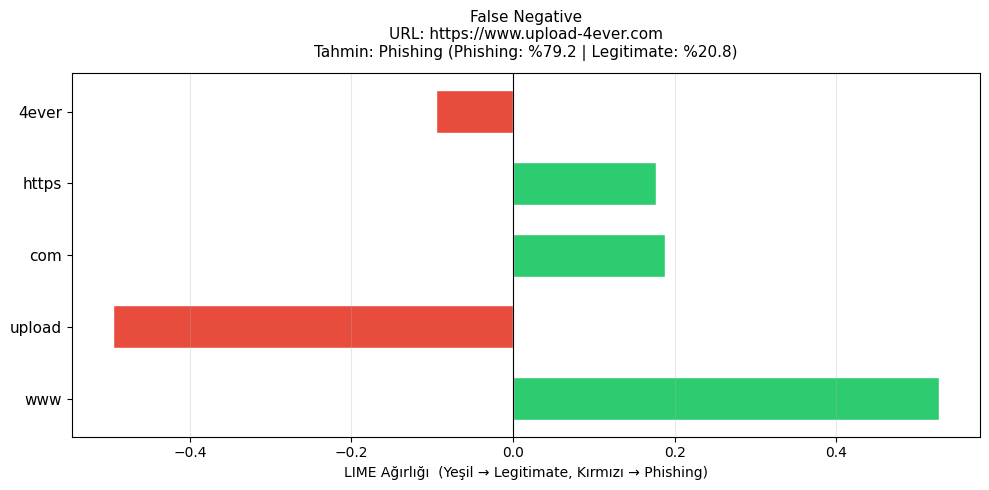

  Kaydedildi: lime_false_negative.png ✓


Tüm LIME analizleri tamamlandı ✓


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def lime_gorseli_olustur(url, baslik, dosya_adi, num_features=8):
    print(f"Analiz ediliyor: {baslik}...")

    exp = explainer.explain_instance(
        url,
        predict_proba,
        num_features=num_features,
        num_samples=500
    )

    # Tahmin olasılıkları
    probs = predict_proba([url])[0]
    pred_label = 'Legitimate' if probs[1] > probs[0] else 'Phishing'

    # Görsel
    fig, ax = plt.subplots(figsize=(10, 5))

    features_weights = exp.as_list()
    features = [fw[0] for fw in features_weights]
    weights  = [fw[1] for fw in features_weights]

    colors = ['#e74c3c' if w < 0 else '#2ecc71' for w in weights]

    bars = ax.barh(range(len(features)), weights, color=colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=11)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME Ağırlığı  (Yeşil → Legitimate, Kırmızı → Phishing)', fontsize=10)
    ax.set_title(f'{baslik}\nURL: {url[:70]}\nTahmin: {pred_label} '
                 f'(Phishing: %{probs[0]*100:.1f} | Legitimate: %{probs[1]*100:.1f})',
                 fontsize=11, pad=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(dosya_adi, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Kaydedildi: {dosya_adi} ✓\n")

    return exp

# Tüm örnekler için LIME analizi yap
print("="*60)
print("LIME ANALİZİ BAŞLIYOR")
print("="*60 + "\n")

lime_sonuclari = {}
for baslik, url in ornek_urls.items():
    dosya = f"lime_{baslik.lower().replace(' ', '_')}.png"
    lime_sonuclari[baslik] = lime_gorseli_olustur(url, baslik, dosya)

print("\nTüm LIME analizleri tamamlandı ✓")

Özellikler çıkarılıyor...
Özellikler hazır ✓

TF-IDF vektörizer eğitiliyor...
TF-IDF hazır ✓

Logistic Regression eğitiliyor...
  F1: 0.9972 ✓

Random Forest eğitiliyor...
  F1: 0.9984 ✓

Model                      Accuracy Precision    Recall        F1
Logistic Regression (TF-IDF)    0.9968    0.9945    1.0000    0.9972
Random Forest (Manuel Özellik)    0.9981    0.9968    0.9999    0.9984
DistilBERT (Bizim Modelimiz)    0.9985    0.9974    0.9999    0.9987


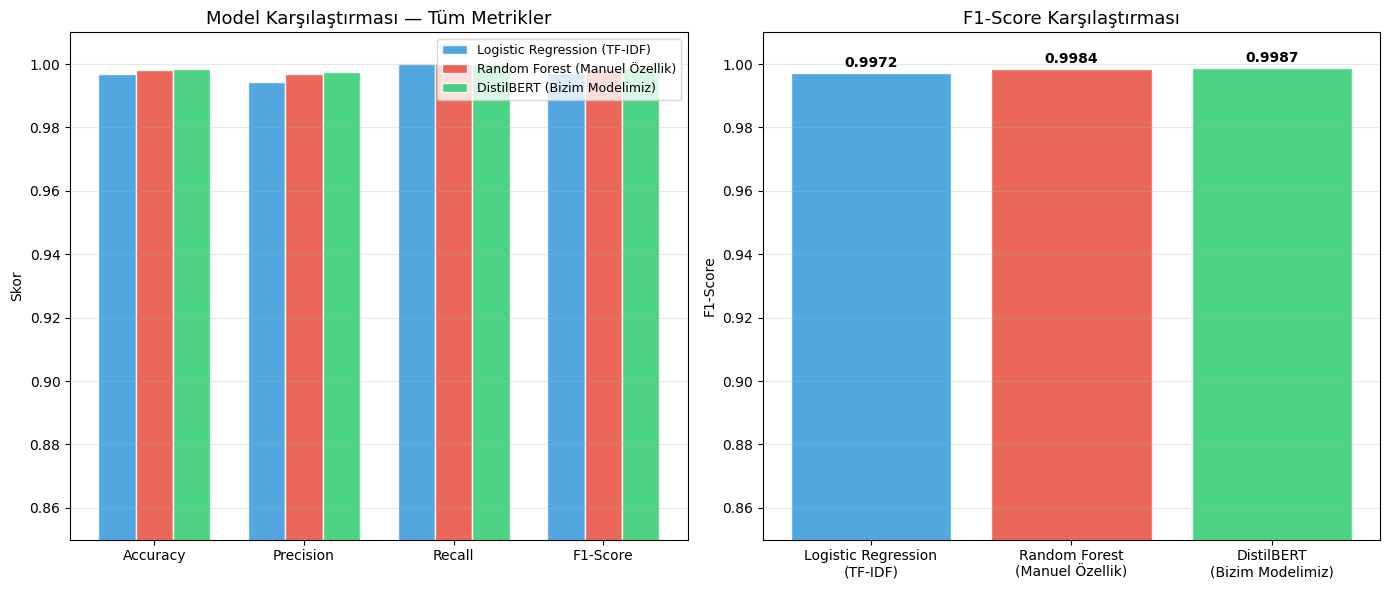

Karşılaştırma grafiği kaydedildi ✓


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# 1. URL'den basit özellikler çıkar
def url_features(url):
    return {
        'length':           len(url),
        'dot_count':        url.count('.'),
        'slash_count':      url.count('/'),
        'hyphen_count':     url.count('-'),
        'digit_count':      sum(c.isdigit() for c in url),
        'special_count':    sum(c in '@?=&%#_~' for c in url),
        'has_https':        int(url.startswith('https')),
        'has_www':          int('www.' in url),
        'has_php':          int('.php' in url),
        'has_login':        int('login' in url.lower()),
        'has_secure':       int('secure' in url.lower()),
        'has_update':       int('update' in url.lower()),
        'subdomain_count':  len(url.split('/')[2].split('.')) - 2 if len(url.split('/')) > 2 else 0,
    }

import pandas as pd

print("Özellikler çıkarılıyor...")
train_features = pd.DataFrame([url_features(u) for u in train_df['URL']])
val_features   = pd.DataFrame([url_features(u) for u in val_df['URL']])
test_features  = pd.DataFrame([url_features(u) for u in test_df['URL']])
print("Özellikler hazır ✓")

# 2. TF-IDF vektörizer (karakter n-gram)
print("\nTF-IDF vektörizer eğitiliyor...")
tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=2
)
train_tfidf = tfidf.fit_transform(train_df['URL'])
val_tfidf   = tfidf.transform(val_df['URL'])
test_tfidf  = tfidf.transform(test_df['URL'])
print("TF-IDF hazır ✓")

# 3. Modelleri eğit ve değerlendir
results = {}

# Logistic Regression (TF-IDF)
print("\nLogistic Regression eğitiliyor...")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(train_tfidf, train_df['label'])
lr_preds = lr.predict(test_tfidf)
results['Logistic Regression\n(TF-IDF)'] = {
    'accuracy':  accuracy_score(test_df['label'], lr_preds),
    'precision': precision_score(test_df['label'], lr_preds),
    'recall':    recall_score(test_df['label'], lr_preds),
    'f1':        f1_score(test_df['label'], lr_preds),
    'sure':      time.time() - t0
}
print(f"  F1: {results['Logistic Regression\n(TF-IDF)']['f1']:.4f} ✓")

# Random Forest (Manuel özellikler)
print("\nRandom Forest eğitiliyor...")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(train_features, train_df['label'])
rf_preds = rf.predict(test_features)
results['Random Forest\n(Manuel Özellik)'] = {
    'accuracy':  accuracy_score(test_df['label'], rf_preds),
    'precision': precision_score(test_df['label'], rf_preds),
    'recall':    recall_score(test_df['label'], rf_preds),
    'f1':        f1_score(test_df['label'], rf_preds),
    'sure':      time.time() - t0
}
print(f"  F1: {results['Random Forest\n(Manuel Özellik)']['f1']:.4f} ✓")

# DistilBERT sonuçlarını ekle
results['DistilBERT\n(Bizim Modelimiz)'] = {
    'accuracy':  test_acc,
    'precision': test_prec,
    'recall':    test_rec,
    'f1':        test_f1,
    'sure':      110  # dakika → saniye
}

# 4. Karşılaştırma tablosu
print("\n" + "="*65)
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>9} {'Recall':>9} {'F1':>9}")
print("="*65)
for model_adi, res in results.items():
    ad = model_adi.replace('\n', ' ')
    print(f"{ad:<25} {res['accuracy']:>9.4f} {res['precision']:>9.4f} "
          f"{res['recall']:>9.4f} {res['f1']:>9.4f}")
print("="*65)

# 5. Karşılaştırma grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_adlari = [k.replace('\n', '\n') for k in results.keys()]
metrikler = ['accuracy', 'precision', 'recall', 'f1']
metrik_adlari = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
renkler = ['#3498db', '#e74c3c', '#2ecc71']

x = range(len(metrikler))
bar_width = 0.25

for i, (model_adi, res) in enumerate(results.items()):
    degerler = [res[m] for m in metrikler]
    offset = [xi + i * bar_width for xi in x]
    axes[0].bar(offset, degerler, bar_width,
                label=model_adi.replace('\n', ' '),
                color=renkler[i], alpha=0.85, edgecolor='white')

axes[0].set_xticks([xi + bar_width for xi in x])
axes[0].set_xticklabels(metrik_adlari)
axes[0].set_ylim([0.85, 1.01])
axes[0].set_title('Model Karşılaştırması — Tüm Metrikler', fontsize=13)
axes[0].set_ylabel('Skor')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# F1 karşılaştırması ayrı
f1_degerler = [res['f1'] for res in results.values()]
bars = axes[1].bar(model_adlari, f1_degerler,
                   color=renkler, alpha=0.85, edgecolor='white')
axes[1].set_ylim([0.85, 1.01])
axes[1].set_title('F1-Score Karşılaştırması', fontsize=13)
axes[1].set_ylabel('F1-Score')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, f1_degerler):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Karşılaştırma grafiği kaydedildi ✓")

In [ ]:
# Tüm sonuçları bir arada kaydet — rapor için
print("="*70)
print("PROJENİN TÜM SONUÇLARI — ÖZET")
print("="*70)

print("\n1. VERİ SETİ: PhiUSIIL (UCI ML Repository)")
print(f"   Toplam: 235.370 URL | Train: 188.296 | Val: 23.537 | Test: 23.537")
print(f"   Phishing: 100.945 | Legitimate: 134.425")

print("\n2. DISTİLBERT EĞİTİM SONUÇLARI:")
print(f"   Epoch 1 → Val F1: 0.9982")
print(f"   Epoch 2 → Val F1: 0.9983")
print(f"   Epoch 3 → Val F1: 0.9983 (en iyi)")

print("\n3. TEST SONUÇLARI (En iyi model):")
print(f"   Accuracy:  {test_acc:.4f}")
print(f"   Precision: {test_prec:.4f}")
print(f"   Recall:    {test_rec:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   Hata sayısı: 36 / 23.537")

print("\n4. BASELINE KARŞILAŞTIRMA:")
print(f"   Logistic Regression (TF-IDF):    F1 = 0.9972")
print(f"   Random Forest (Manuel Özellik):  F1 = 0.9984")
print(f"   DistilBERT (Bizim Modelimiz):    F1 = 0.9987 ← EN İYİ")

print("\n5. HATA ANALİZİ:")
print(f"   False Positive: 35 (Phishing → Legitimate sanıldı)")
print(f"   False Negative:  1 (Legitimate → Phishing sanıldı)")

print("\n6. XAI (LIME) BULGULARI:")
print("   - HTTP protokolü phishing sinyali olarak öğrenildi")
print("   - 'www' varlığı legitimate sinyali olarak öğrenildi")
print("   - Rastgele sayılar (sitebuilder186891) şüpheli bulundu")
print("   - .php, updsoci, cc gibi path segmentleri phishing sinyali")
print("   - 'upload', '4ever' gibi kelimeler şüpheli bulundu")

print("\n" + "="*70)
print("TÜM DENEYSEL ÇALIŞMALAR TAMAMLANDI ✓")
print("="*70)

PROJENİN TÜM SONUÇLARI — ÖZET

1. VERİ SETİ: PhiUSIIL (UCI ML Repository)
   Toplam: 235.370 URL | Train: 188.296 | Val: 23.537 | Test: 23.537
   Phishing: 100.945 | Legitimate: 134.425

2. DISTİLBERT EĞİTİM SONUÇLARI:
   Epoch 1 → Val F1: 0.9982
   Epoch 2 → Val F1: 0.9983
   Epoch 3 → Val F1: 0.9983 (en iyi)

3. TEST SONUÇLARI (En iyi model):
   Accuracy:  0.9985
   Precision: 0.9974
   Recall:    0.9999
   F1-Score:  0.9987
   Hata sayısı: 36 / 23.537

4. BASELINE KARŞILAŞTIRMA:
   Logistic Regression (TF-IDF):    F1 = 0.9972
   Random Forest (Manuel Özellik):  F1 = 0.9984
   DistilBERT (Bizim Modelimiz):    F1 = 0.9987 ← EN İYİ

5. HATA ANALİZİ:
   False Positive: 35 (Phishing → Legitimate sanıldı)
   False Negative:  1 (Legitimate → Phishing sanıldı)

6. XAI (LIME) BULGULARI:
   - HTTP protokolü phishing sinyali olarak öğrenildi
   - 'www' varlığı legitimate sinyali olarak öğrenildi
   - Rastgele sayılar (sitebuilder186891) şüpheli bulundu
   - .php, updsoci, cc gibi path segmentl